# Notebook 4: Prediction Demo

This notebook puts our trained models into practice with two interactive demos:

1. **Player Valuation Predictor** — Enter any player name (fuzzy matched) and get a prediction of their market value for the next season half, powered by the LightGBM model selected in Notebook 2.

2. **Hidden Gems Shortlist** — Apply the XGBoost burst classifier from Notebook 3 to the latest available data for all players, surfacing the top candidates most likely to see a major valuation surge over the next 2 years.

Both models are retrained here on the **full dataset** (all available seasons) to maximise prediction quality for forward-looking use. In contrast, Notebooks 2 and 3 held out a test set to evaluate generalisation — here we prioritise coverage and accuracy for deployment.

## I. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from rapidfuzz import process as fuzz_process, fuzz

## II. Data Loading

We load two tables:
- **`dataset.csv`** — engineered feature dataset with one row per player per season half (used to train both models)
- **`players.csv`** — player biographical data (used for name lookup and display)

In [2]:
dataset = pd.read_csv('../../data/dataset.csv')

# Exclude 'position' from players.csv — dataset.csv already has it and we must avoid
# column name conflicts (which would rename 'position' to 'position_x' after the merge)
players = pd.read_csv('../../data/players.csv')[['player_id', 'name', 'current_club_name', 'country_of_birth']]

print(f"Dataset shape : {dataset.shape}")
print(f"Players shape : {players.shape}")
print(f"Season periods: {sorted(dataset['season_period'].unique())}")
print(f"Unique players: {dataset['player_id'].nunique()}")

Dataset shape : (41907, 82)
Players shape : (34291, 4)
Season periods: ['2012-2013_H1', '2012-2013_H2', '2013-2014_H1', '2013-2014_H2', '2014-2015_H1', '2014-2015_H2', '2015-2016_H1', '2015-2016_H2', '2016-2017_H1', '2016-2017_H2', '2017-2018_H1', '2017-2018_H2', '2018-2019_H1', '2018-2019_H2', '2019-2020_H1', '2019-2020_H2', '2020-2021_H1', '2020-2021_H2', '2021-2022_H1', '2021-2022_H2', '2022-2023_H1']
Unique players: 8093


## III. Feature Engineering & Model Training

### Feature Definitions

We define the same column groups used in Notebooks 2 and 3:
- **Meta columns** — identifiers used for splitting/joining, not model inputs
- **Leakage columns** — derived from future data; excluded from training
- **Categorical columns** — one-hot encoded before training

In [3]:
META_COLS    = ['player_id', 'season_period', 'domestic_competition_id', 'player_club_id', 'period_rank']
LEAKAGE_COLS = ['valuation_2y_ahead', 'valuation_log_change_2y', 'label_burst',
                'label_rapid_decline', 'date_of_birth', 'points_earned']
CAT_COLS     = ['position', 'foot', 'career_stage']

VALUATION_TARGET = 'next_valuation'
BURST_TARGET     = 'label_burst'

# All feature columns (shared by both models)
feature_cols = [c for c in dataset.columns
                if c not in META_COLS + LEAKAGE_COLS + [VALUATION_TARGET, 'next_valuation']]

print(f"Feature columns ({len(feature_cols)}):")
print(feature_cols)

Feature columns (70):
['goals', 'assists', 'yellow_cards', 'red_cards', 'minutes_played', 'games_played', 'result', 'position', 'foot', 'height_in_cm', 'age', 'home_club_goals', 'away_club_goals', 'squad_size', 'average_age', 'foreigners_number', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'period_end_valuation', 'goal_contributions', 'goal_contributions_per_game', 'goals_per_90', 'assists_per_90', 'goals_momentum', 'assists_momentum', 'minutes_momentum', 'games_momentum', 'years_to_peak', 'age_x_goals_per_90', 'career_stage', 'availability_rate', 'is_regular_starter', 'cards_per_game', 'team_avg_goals', 'goal_share', 'contribution_share', 'is_top5_league', 'win_rate', 'period_end_valuation_lag1', 'period_end_valuation_lag2', 'period_end_valuation_rolling2_mean', 'goals_lag1', 'goals_lag2', 'goals_rolling2_mean', 'assists_lag1', 'assists_lag2', 'assists_rolling2_mean', 'minutes_played_lag1', 'minutes_played_lag2', 'minutes_played_rolling2_mean', 'games_played_lag1', 'game

In [4]:
# Build the model feature matrix (one-hot encode categoricals)
X_all = dataset[feature_cols].copy()
X_all = pd.get_dummies(X_all, columns=CAT_COLS, drop_first=False)

y_valuation = np.log1p(dataset[VALUATION_TARGET])
y_burst      = dataset[BURST_TARGET]

print(f"X_all shape     : {X_all.shape}")
print(f"Model features  : {X_all.columns.tolist()}")

X_all shape     : (41907, 79)
Model features  : ['goals', 'assists', 'yellow_cards', 'red_cards', 'minutes_played', 'games_played', 'result', 'height_in_cm', 'age', 'home_club_goals', 'away_club_goals', 'squad_size', 'average_age', 'foreigners_number', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'period_end_valuation', 'goal_contributions', 'goal_contributions_per_game', 'goals_per_90', 'assists_per_90', 'goals_momentum', 'assists_momentum', 'minutes_momentum', 'games_momentum', 'years_to_peak', 'age_x_goals_per_90', 'availability_rate', 'is_regular_starter', 'cards_per_game', 'team_avg_goals', 'goal_share', 'contribution_share', 'is_top5_league', 'win_rate', 'period_end_valuation_lag1', 'period_end_valuation_lag2', 'period_end_valuation_rolling2_mean', 'goals_lag1', 'goals_lag2', 'goals_rolling2_mean', 'assists_lag1', 'assists_lag2', 'assists_rolling2_mean', 'minutes_played_lag1', 'minutes_played_lag2', 'minutes_played_rolling2_mean', 'games_played_lag1', 'games_played_l

### 3.1 LightGBM — Valuation Model

We retrain the LightGBM regressor (best model from Notebook 2) on all available data. The target is log1p-transformed to handle the right-skewed valuation distribution; predictions are back-transformed with `expm1`.

In [5]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(X_all, y_valuation)
print("LightGBM valuation model trained on", len(X_all), "records.")

LightGBM valuation model trained on 41907 records.


### 3.2 XGBoost — Burst Classifier

We retrain the XGBoost burst classifier (from Notebook 3) on the full dataset. Class imbalance is handled with `scale_pos_weight`.

In [7]:
n_pos = y_burst.sum()
n_neg = len(y_burst) - n_pos
scale_pos_weight_burst = n_neg / n_pos
print(f"Burst class balance: {n_pos:,} positive / {n_neg:,} negative  (scale_pos_weight = {scale_pos_weight_burst:.1f})")

burst_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_burst,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=0,
    n_jobs=-1,
)

burst_clf.fit(X_all, y_burst)
print("XGBoost burst classifier trained on", len(X_all), "records.")

Burst class balance: 1,817 positive / 40,090 negative  (scale_pos_weight = 22.1)
XGBoost burst classifier trained on 41907 records.


### 3.3 Latest Player Records

For predictions, we use each player's **most recent** season record as the input features. This represents their latest known performance and valuation state.

In [8]:
# Most recent record per player (sorted by period_rank)
latest_records = (
    dataset.sort_values('period_rank')
    .groupby('player_id')
    .last()
    .reset_index()
)

# Merge player names for display
latest_records = latest_records.merge(players, on='player_id', how='left')

print(f"Latest records: {len(latest_records)} players")
print()
print("Season period distribution of latest records:")
print(latest_records['season_period'].value_counts().sort_index().tail(8))

Latest records: 8093 players

Season period distribution of latest records:
season_period
2018-2019_H2     176
2019-2020_H1     831
2019-2020_H2     136
2020-2021_H1    1279
2020-2021_H2      53
2021-2022_H1    1007
2021-2022_H2      16
2022-2023_H1       8
Name: count, dtype: int64


## IV. Demo 1 — Player Valuation Predictor

**How it works:**
1. Enter a player name (partial names and typos are handled by fuzzy matching)
2. The model looks up the player's latest available record as input features
3. LightGBM predicts their market value for the next season half
4. The result is shown alongside their current valuation and implied change

In [9]:
def find_player(query, top_n=5):
    """Fuzzy match a query string against all player names. Returns top_n matches."""
    all_names = latest_records['name'].dropna().unique().tolist()
    matches = fuzz_process.extract(query, all_names, scorer=fuzz.WRatio, limit=top_n)
    results = []
    for name, score, _ in matches:
        row = latest_records[latest_records['name'] == name].iloc[0]
        results.append({
            'name':              row['name'],
            'club':              row.get('current_club_name', 'Unknown'),
            'position':          row.get('position', 'Unknown'),
            'latest_season':     row['season_period'],
            'current_value_EUR': row['period_end_valuation'],
            'player_id':         row['player_id'],
            'match_score':       score,
        })
    return pd.DataFrame(results)


def predict_valuation(player_id):
    """Predict next-period valuation for a player given their latest record."""
    row = latest_records[latest_records['player_id'] == player_id]
    if row.empty:
        raise ValueError(f"player_id {player_id} not found.")

    # Build feature row (same pipeline as training)
    X_input = row[feature_cols].copy()
    X_input = pd.get_dummies(X_input, columns=CAT_COLS, drop_first=False)

    # Align columns with training data (fill any missing dummies with 0)
    X_input = X_input.reindex(columns=X_all.columns, fill_value=0)

    pred_log = lgb_model.predict(X_input)[0]
    pred_eur = np.expm1(pred_log)

    current_eur = row['period_end_valuation'].values[0]
    pct_change  = (pred_eur - current_eur) / current_eur * 100 if current_eur > 0 else float('nan')

    return {
        'current_value_EUR':   current_eur,
        'predicted_value_EUR': pred_eur,
        'pct_change':          pct_change,
        'latest_season':       row['season_period'].values[0],
    }

### Search & Predict

Run the cell below to search for a player by name and predict their next-period valuation.

> **To try a different player:** change `PLAYER_QUERY` to any name (e.g. `"Mbappe"`, `"De Bruyne"`, `"Haaland"`).

In [10]:
PLAYER_QUERY = "Kylian Mbappe"

# Step 1: fuzzy match
print(f"Searching for: '{PLAYER_QUERY}'")
print()
candidates = find_player(PLAYER_QUERY, top_n=5)
print("Top matches:")
print(candidates[['name', 'club', 'position', 'latest_season', 'current_value_EUR', 'match_score']]
      .to_string(index=False))

Searching for: 'Kylian Mbappe'

Top matches:
         name                                                club position latest_season  current_value_EUR  match_score
Kylian Mbappé                          Real Madrid Club de Fútbol   Attack  2020-2021_H1          180000000    92.307692
         Alan                             Sporting Clube de Braga   Attack  2014-2015_H1            1200000    67.500000
  Dylan Mbayo                                         KV Kortrijk   Attack  2020-2021_H1             800000    66.666667
Kylian Hazard                                       RWD Molenbeek   Attack  2018-2019_H1             700000    61.538462
 Mbaye Diagne Fatih Karagümrük Sportif Faaliyetler San. Tic. A.Ş.   Attack  2020-2021_H1            3200000    60.800000


In [11]:
# Step 2: predict for the best match
best_match = candidates.iloc[0]
result = predict_valuation(best_match['player_id'])

print(f"Player            : {best_match['name']}")
print(f"Club              : {best_match['club']}")
print(f"Latest data from  : {result['latest_season']}")
print()
print(f"Current valuation : EUR {result['current_value_EUR']:>15,.0f}")
print(f"Predicted next    : EUR {result['predicted_value_EUR']:>15,.0f}")
print(f"Implied change    : {result['pct_change']:>+.1f}%")

Player            : Kylian Mbappé
Club              : Real Madrid Club de Fútbol
Latest data from  : 2020-2021_H1

Current valuation : EUR     180,000,000
Predicted next    : EUR     151,543,741
Implied change    : -15.8%


### Visualisation

The bar chart below puts the predicted valuation in context alongside the player's current value.

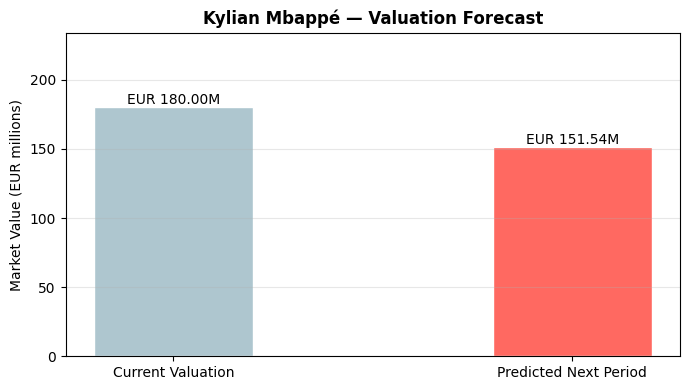

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['Current Valuation', 'Predicted Next Period']
values = [result['current_value_EUR'], result['predicted_value_EUR']]
colors = ['#aec6cf', '#77dd77' if result['pct_change'] >= 0 else '#ff6961']

bars = ax.bar(labels, [v / 1e6 for v in values], color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"EUR {val/1e6:.2f}M", ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Market Value (EUR millions)')
ax.set_title(f"{best_match['name']} — Valuation Forecast", fontweight='bold')
ax.set_ylim(0, max(values) / 1e6 * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## V. Demo 2 — Hidden Gems Shortlist

**How it works:**
1. The burst classifier scores every player in the dataset using their latest available record
2. Players are ranked by predicted burst probability (descending)
3. The top candidates are displayed as an actionable scouting shortlist

A "burst player" is defined as a currently undervalued player (current valuation <= median ~EUR 2.5M) whose market value is expected to increase by ~6.7x over the next 2 years. The model was trained on this definition (see Notebook 3 for details).

> **Note:** Since we are using each player's most recent available record (not a held-out set), these predictions represent the model's best forward-looking estimate rather than a rigorous out-of-sample evaluation.

In [13]:
# Build feature matrix for all latest records
X_latest = latest_records[feature_cols].copy()
X_latest = pd.get_dummies(X_latest, columns=CAT_COLS, drop_first=False)
X_latest = X_latest.reindex(columns=X_all.columns, fill_value=0)

# Predict burst probability for every player
burst_proba = burst_clf.predict_proba(X_latest)[:, 1]

# Assemble results table
gems_df = latest_records[['player_id', 'name', 'current_club_name', 'season_period',
                           'period_end_valuation', 'age', 'position']].copy()
gems_df['burst_probability'] = burst_proba

# Filter to undervalued players (current valuation <= EUR 2.5M) — consistent with burst label definition
gems_df = gems_df[gems_df['period_end_valuation'] <= 2_500_000].copy()

# Sort by predicted probability
gems_df = gems_df.sort_values('burst_probability', ascending=False).reset_index(drop=True)

print(f"Undervalued players scored: {len(gems_df)}")
print(f"Players with burst probability > 0.5: {(gems_df['burst_probability'] > 0.5).sum()}")
print(f"Players with burst probability > 0.3: {(gems_df['burst_probability'] > 0.3).sum()}")

Undervalued players scored: 5246
Players with burst probability > 0.5: 627
Players with burst probability > 0.3: 873


### Top 20 Predicted Hidden Gems

In [14]:
TOP_K = 20

top_gems = gems_df.head(TOP_K).copy()
top_gems.index = range(1, TOP_K + 1)
top_gems['current_value'] = top_gems['period_end_valuation'].apply(lambda x: f"EUR {x/1e6:.2f}M")
top_gems['burst_prob']    = top_gems['burst_probability'].apply(lambda x: f"{x:.1%}")
top_gems['age']           = top_gems['age'].apply(lambda x: f"{x:.0f}")

display_cols = ['name', 'current_club_name', 'position', 'age', 'season_period', 'current_value', 'burst_prob']
display_df = top_gems[display_cols].rename(columns={
    'name':              'Player',
    'current_club_name': 'Club',
    'position':          'Position',
    'age':               'Age',
    'season_period':     'Latest Data',
    'current_value':     'Current Value',
    'burst_prob':        'Burst Prob.',
})

print(f"Top {TOP_K} Predicted Hidden Gems (undervalued players most likely to surge in value):")
print()
print(display_df.to_string())

Top 20 Predicted Hidden Gems (undervalued players most likely to surge in value):

                     Player                                                    Club  Position Age   Latest Data Current Value Burst Prob.
1              Tim Hölscher                                    Football Club Twente  Midfield  18  2012-2013_H1     EUR 0.05M       99.9%
2            Valeriy Bondar                                     FC Shakhtar Donetsk  Defender  21  2019-2020_H1     EUR 0.05M       99.9%
3      Maximilian Eggestein                                     Sport-Club Freiburg  Midfield  21  2017-2018_H1     EUR 0.50M       99.9%
4               Marius Wolf                              Fußball-Club Augsburg 1907  Defender  23  2017-2018_H1     EUR 0.35M       99.8%
5             Dennis Geiger                                  Aberdeen Football Club  Midfield  20  2017-2018_H1     EUR 0.12M       99.8%
6          Marvin Friedrich  Borussia Verein für Leibesübungen 1900 Mönchengladbach  Defe

### Burst Probability Distribution

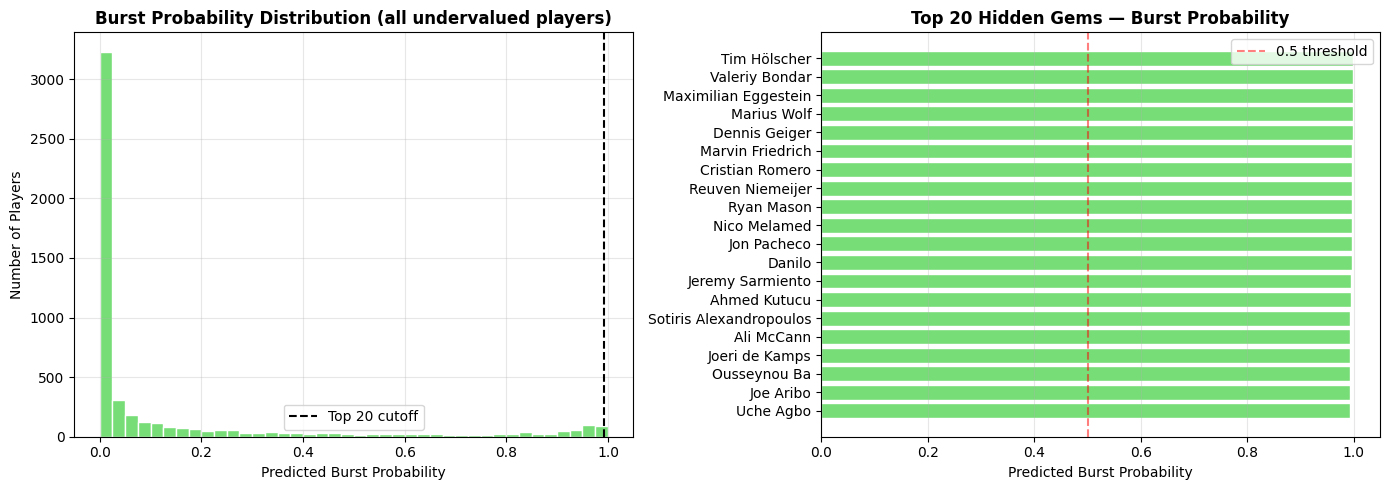

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of burst probability for all undervalued players
axes[0].hist(gems_df['burst_probability'], bins=40, color='#77dd77', edgecolor='white')
axes[0].axvline(gems_df.head(TOP_K)['burst_probability'].min(),
                color='black', linestyle='--', label=f'Top {TOP_K} cutoff')
axes[0].set_title('Burst Probability Distribution (all undervalued players)', fontweight='bold')
axes[0].set_xlabel('Predicted Burst Probability')
axes[0].set_ylabel('Number of Players')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart: top 20 players by burst probability
axes[1].barh(
    top_gems['name'].values[::-1],
    top_gems['burst_probability'].values[::-1],
    color='#77dd77', edgecolor='white'
)
axes[1].set_title(f'Top {TOP_K} Hidden Gems — Burst Probability', fontweight='bold')
axes[1].set_xlabel('Predicted Burst Probability')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## VI. Bonus — Veteran Watch List (Rapid Decline)

Using the same approach as the hidden gems shortlist, we can also identify veteran players most at risk of a steep valuation decline. These are players aged 30+ whose model-predicted decline probability is highest — useful for sell-or-hold decisions.

In [16]:
DECLINE_TARGET = 'label_rapid_decline'
y_decline      = dataset[DECLINE_TARGET]

n_pos_d = y_decline.sum()
n_neg_d = len(y_decline) - n_pos_d
scale_pos_weight_decline = n_neg_d / n_pos_d

decline_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_decline,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=0,
    n_jobs=-1,
)

decline_clf.fit(X_all, y_decline)
print("Decline classifier trained on", len(X_all), "records.")

Decline classifier trained on 41907 records.


In [17]:
decline_proba = decline_clf.predict_proba(X_latest)[:, 1]

decline_df = latest_records[['player_id', 'name', 'current_club_name', 'season_period',
                              'period_end_valuation', 'age', 'position']].copy()
decline_df['decline_probability'] = decline_proba

# Filter to veterans aged >= 30 — consistent with label definition
decline_df = decline_df[decline_df['age'] >= 30].copy()
decline_df = decline_df.sort_values('decline_probability', ascending=False).reset_index(drop=True)

print(f"Veterans (age >= 30) scored: {len(decline_df)}")
print(f"Players with decline probability > 0.5: {(decline_df['decline_probability'] > 0.5).sum()}")

Veterans (age >= 30) scored: 1789
Players with decline probability > 0.5: 436


Top 20 Veterans Most at Risk of Rapid Valuation Decline:

                    Player                                                     Club    Position Age   Latest Data Current Value Decline Prob.
1                   Edinho                                              CD Feirense      Attack  32  2014-2015_H1     EUR 2.50M         99.6%
2   Bastian Schweinsteiger                          Manchester United Football Club    Midfield  30  2014-2015_H1    EUR 35.00M         99.6%
3         Laurent Depoitre                     Koninklijke Atletiek Associatie Gent      Attack  32  2020-2021_H1     EUR 2.50M         99.5%
4              Pierre Webó                                               Ankaraspor      Attack  33  2014-2015_H1     EUR 3.50M         99.5%
5                 Demba Ba                        İstanbul Başakşehir Futbol Kulübü      Attack  32  2016-2017_H2     EUR 4.50M         99.5%
6         Vladimir Bystrov                                         FC Tosno (-2018)    Mid

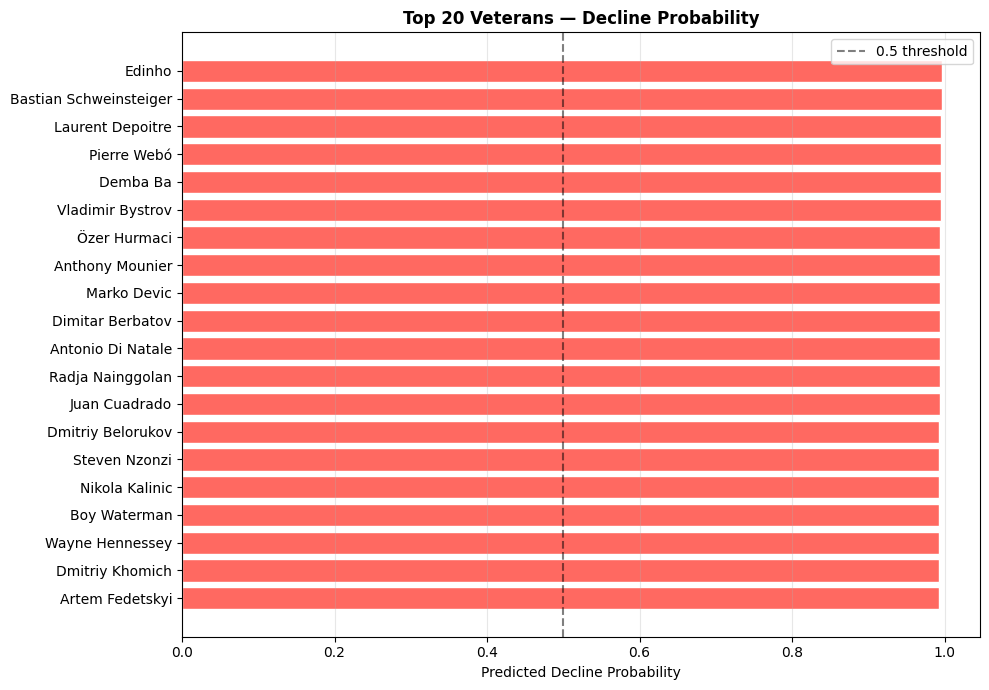

In [18]:
TOP_K_DECLINE = 20

top_decline = decline_df.head(TOP_K_DECLINE).copy()
top_decline.index = range(1, TOP_K_DECLINE + 1)
top_decline['current_value'] = top_decline['period_end_valuation'].apply(lambda x: f"EUR {x/1e6:.2f}M")
top_decline['decline_prob']  = top_decline['decline_probability'].apply(lambda x: f"{x:.1%}")
top_decline['age']           = top_decline['age'].apply(lambda x: f"{x:.0f}")

display_cols = ['name', 'current_club_name', 'position', 'age', 'season_period', 'current_value', 'decline_prob']
display_df_d = top_decline[display_cols].rename(columns={
    'name':              'Player',
    'current_club_name': 'Club',
    'position':          'Position',
    'age':               'Age',
    'season_period':     'Latest Data',
    'current_value':     'Current Value',
    'decline_prob':      'Decline Prob.',
})

print(f"Top {TOP_K_DECLINE} Veterans Most at Risk of Rapid Valuation Decline:")
print()
print(display_df_d.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_decline['name'].values[::-1],
    top_decline['decline_probability'].values[::-1],
    color='#ff6961', edgecolor='white'
)
ax.set_title(f'Top {TOP_K_DECLINE} Veterans — Decline Probability', fontweight='bold')
ax.set_xlabel('Predicted Decline Probability')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='0.5 threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## VII. Summary

This notebook demonstrated three end-to-end prediction use cases:

| Demo | Model | Input | Output |
|------|-------|-------|--------|
| Player valuation predictor | LightGBM (regressor) | Player name (fuzzy search) | Predicted market value next season half |
| Hidden gems shortlist | XGBoost (classifier) | All undervalued players (<=EUR 2.5M) | Ranked list by burst probability |
| Veteran watch list | XGBoost (classifier) | All veterans (age >= 30) | Ranked list by decline probability |

### How to Use

- **Valuation predictor:** Change `PLAYER_QUERY` in Section IV to any player name and re-run the two prediction cells.
- **Hidden gems:** Adjust `TOP_K` to change the shortlist length. Add age or positional filters to `gems_df` to narrow the scouting scope.
- **Veteran watch list:** Similarly adjust `TOP_K_DECLINE` or filter by club, league, or contract status for targeted sell decisions.

### Caveats

- All models are trained on data up to **2022-2023_H1**. Predictions for players whose form has significantly changed after this point may be less reliable.
- The models capture patterns at the **season-half level**. Intra-season events (injuries, managerial changes, transfers) are not reflected until the next data update.
- Transfermarkt valuations are crowd-sourced estimates, not market prices. Model predictions inherit this noise.